In [63]:
import uproot, numpy as np, matplotlib.pyplot as plt
print(uproot.__version__)

5.7.5


In [86]:
f = uproot.open("../build/target_run.root")

(0.0, 25.0)

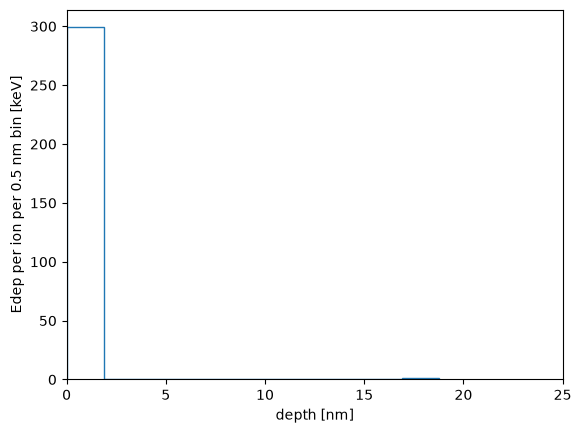

In [87]:
vals, edges = f["EdepZ"].to_numpy()
vals_keV_per_ion = vals * 1e3 / 10000        # MeV -> keV, per primary (energy deposition per ion conversion)
#plt.stairs(vals_keV_per_ion, edges*1e6)
plt.hist(vals_keV_per_ion, bins=10, histtype="step", color="C0", label="Edep per ion per 0.5 nm bin [keV]")
plt.xlabel("depth [nm]"); plt.ylabel("Edep per ion per 0.5 nm bin [keV]")
plt.xlim(0, 25)

10128


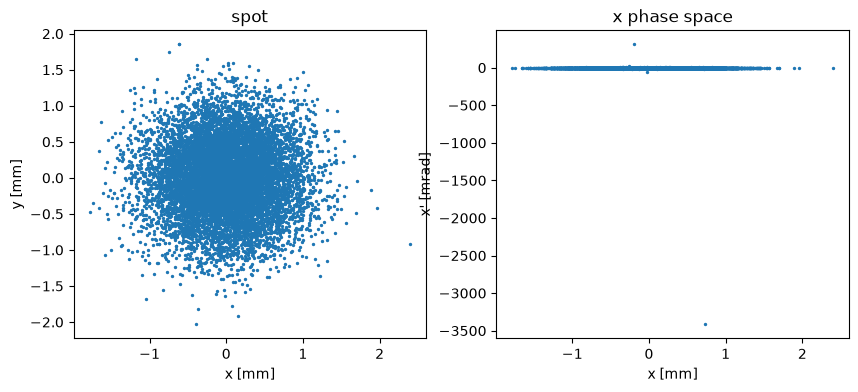

In [81]:
# Beam scatter + phase space
b = f["beam"].arrays(library="np")
print(b["x"].size);
fig, ax = plt.subplots(1, 2, figsize=(10,4))
ax[0].scatter(b["x"], b["y"], s=2);  ax[0].set(xlabel="x [mm]", ylabel="y [mm]", title="spot")
ax[1].scatter(b["x"], b["xp"], s=2); ax[1].set(xlabel="x [mm]", ylabel="x' [mrad]", title="x phase space") 
plt.show()

# do gaussian fit & energy distribution

0 re-entry/degraded rows


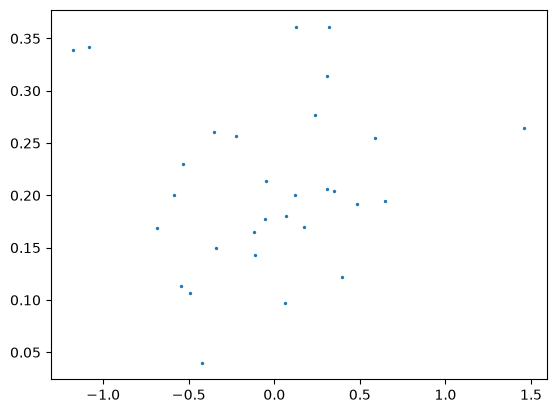

In [59]:
# test hard back-scattering, volume re-entry so check only for particles where E = Ebeam, significantly less -> back-scattered
import numpy as np
m = b["E"] > 20.0     # keV; generous first-entry gate
print(len(b["E"]) - m.sum(), "re-entry/degraded rows")
plt.scatter(b["x"][m], b["xp"][m]*1e3, s=2)